# Urine Data Analysis (Obese Cohort)

With the cleaned and individually exported data, the dataset is now ready for detailed analysis. The urine lab data will be analyzed first, followed by blood lab analyses.

From the cleaned urine labs, the focus will be on values that are more directly associated with metabolic syndrome and related conditions. The urine labs selected for analysis are:

* Albumin – Used to assess kidney function and nutritional status.
* Creatinine – Another key marker of kidney function.
* Iodine – An essential element for thyroid function, which plays a direct role in metabolism.

These analytes were chosen for their relevance to metabolic health and potential associations with obesity and related physiological outcomes.

For the purposes of this data analysis project, the focus will be on adult subjects with BMI between and including 30 and 50.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import linregress

In [2]:
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

In [3]:
current_directory = os.getcwd()
print(current_directory)

C:\Users\chungs4\Documents\GitHub\portfolio_ds_projects\NHANES_analysis


In [4]:
df_d = pd.read_csv('cleaned_demographics.csv')
df_a = pd.read_csv('cleaned_anthropometry.csv')
df_cr = pd.read_csv('urine_cr_alb.csv')

In [5]:
df_d.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
0,109263.0,1.0,2.0,6.0,NaN,NaN,4.66
1,109264.0,2.0,13.0,1.0,NaN,NaN,0.83
2,109265.0,1.0,2.0,3.0,NaN,NaN,3.06
3,109266.0,2.0,29.0,6.0,5.0,3.0,5.00
4,109269.0,1.0,2.0,2.0,NaN,NaN,0.96


In [6]:
df_d.isna().sum()

participant_id              0
gender                      0
age_year                    0
race                        0
education_level          5756
marital_status           5756
family_income_poverty    1847
dtype: int64

In [7]:
df_d.describe()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
count,14300.000000,14300.000000,14300.000000,14300.000000,8544.000000,8544.000000,12453.000000
mean,117068.670280,1.504545,33.861818,3.482797,3.554775,1.694640,2.385320
std,4501.643618,0.499997,25.162121,1.625440,1.210994,2.613598,1.625954
min,109263.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,113170.750000,1.000000,10.000000,3.000000,3.000000,1.000000,1.010000
50%,117081.500000,2.000000,31.000000,3.000000,4.000000,1.000000,1.940000
75%,120974.250000,2.000000,56.000000,4.000000,4.000000,2.000000,3.850000
max,124822.000000,2.000000,80.000000,7.000000,9.000000,99.000000,5.000000


In [8]:
adults = df_d[df_d['age_year'] >= 18]

In [9]:
adults.describe()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
count,8965.000000,8965.000000,8965.000000,8965.000000,8544.000000,8544.000000,7705.000000
mean,117107.849637,1.513999,49.465142,3.484551,3.554775,1.694640,2.558740
std,4501.048325,0.499832,18.457564,1.574461,1.210994,2.613598,1.627623
min,109266.000000,1.000000,18.000000,1.000000,1.000000,1.000000,0.000000
25%,113211.000000,1.000000,33.000000,3.000000,3.000000,1.000000,1.170000
50%,117091.000000,2.000000,50.000000,3.000000,4.000000,1.000000,2.160000
75%,121022.000000,2.000000,64.000000,4.000000,4.000000,2.000000,4.140000
max,124822.000000,2.000000,80.000000,7.000000,9.000000,99.000000,5.000000


The data frame `adults` was created by only including subjects aged 18 or greater from the demographics dataset. The next step will be to clean the anthropometry dataset by dropping any NaN values in the BMI column, removing unnecessary columns (columns relating to pediatric anthropometry), and merging the datasets `adults` with `df_a`.



In [10]:
df_a.isna().sum()

participant_id                 0
weight_kg                     32
weight_comment             13519
recumbent_length_cm        12637
standing_height              950
standing_height_comment    13936
bmi                          970
bmi_category_child          9358
upper_leg_cm                3123
upper_arm_cm                 617
arm_circumference_cm         623
waist_circ_cm               1533
hip_circ_cm                 4245
dtype: int64

In [11]:
df_a = df_a.dropna(subset=['bmi'])

In [12]:
df_a.isna().sum()

participant_id                 0
weight_kg                      0
weight_comment             12601
recumbent_length_cm        12571
standing_height                0
standing_height_comment    13038
bmi                            0
bmi_category_child          8388
upper_leg_cm                2177
upper_arm_cm                 460
arm_circumference_cm         461
waist_circ_cm                603
hip_circ_cm                 3296
dtype: int64

In [13]:
df_a.columns

Index(['participant_id', 'weight_kg', 'weight_comment', 'recumbent_length_cm',
       'standing_height', 'standing_height_comment', 'bmi',
       'bmi_category_child', 'upper_leg_cm', 'upper_arm_cm',
       'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm'],
      dtype='object')

In [14]:
df_a = df_a.drop(['recumbent_length_cm','bmi_category_child','weight_comment'], axis = 1)

In [15]:
adults_joined = adults.merge(df_a, on='participant_id')

#### Descriptive Statistics

At this point, the data frame including anthropometry of all of the adults subjects has been created. The first thing to do before focusing on the obese population, a basic descriptive statistics was performed to show the BMI distribution. 

First, a box and whiskers chart was created to display the distribution overall. Median and average of the BMI are in the overweight range. Next, the decision was made to separate the population by gender. The result was similar; however, women had higher average BMI compared to the males in the cohort. 

In [16]:
adults_joined['bmi'].describe()

count    8790.000000
mean       29.883413
std         7.603916
min        14.200000
25%        24.700000
50%        28.600000
75%        33.600000
max        92.300000
Name: bmi, dtype: float64

In [17]:
# Create a mapping for gender labels
gender_labels = {1: "Male", 2: "Female"}

# Replace gender values with text labels for plotting
adults_joined["gender_label"] = adults_joined["gender"].map(gender_labels)

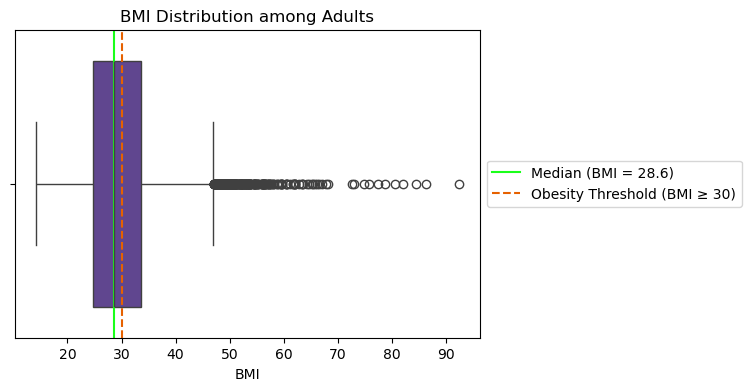

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='bmi', data=adults_joined, color = '#5D3A9B')

# Calculate median
median_val = adults_joined['bmi'].median()

# Add vertical line for the median and include it in the legend
plt.axvline(median_val, color='#1AFF1A', linestyle='-', label=f"Median (BMI = {median_val:.1f})")

# Obesity threshold line
plt.axvline(30, color='#E66100', linestyle='--', label="Obesity Threshold (BMI ≥ 30)")

plt.title("BMI Distribution among Adults")
plt.xlabel("BMI")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

As we can see, even at average, the weight distribution among adults doesn't fall into normal weight. In fact, the mean weight of this dataset, which is supposed to mimic the American population, is in the upper range of overweight bordering obesity. The weight of the Americans are overall increased.

<Axes: xlabel='bmi', ylabel='Count'>

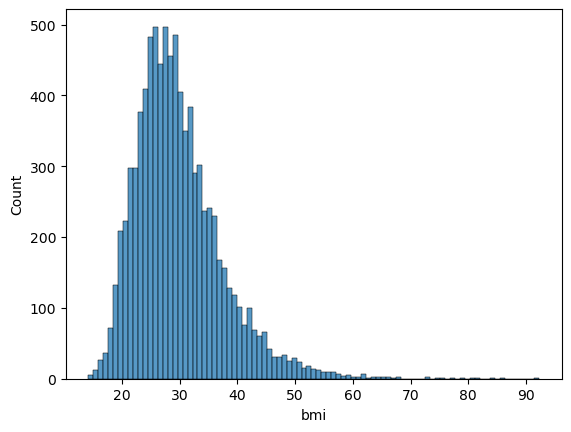

In [19]:
sns.histplot(data=adults_joined, x="bmi")


(30.0, 50.0)

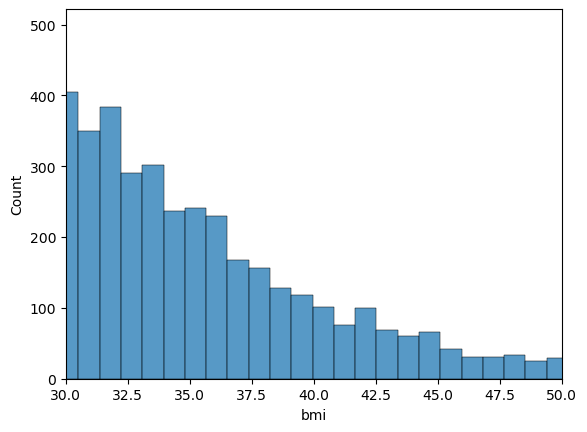

In [20]:
sns.histplot(data=adults_joined, x="bmi")
plt.xlim(30, 50)

Although the BMI distribution in the overall population is right-skewed, restricting the analysis to participants with BMI 30–50 results in a truncated but adequately variable distribution within the obese range. Because statistical power primarily depends on sample size and variability rather than perfect normality, and given the large sample size of NHANES, mild skewness within this restricted range is unlikely to bias parameter estimates or meaningfully affect power. Analyses were interpreted as conditional on the obese subset.

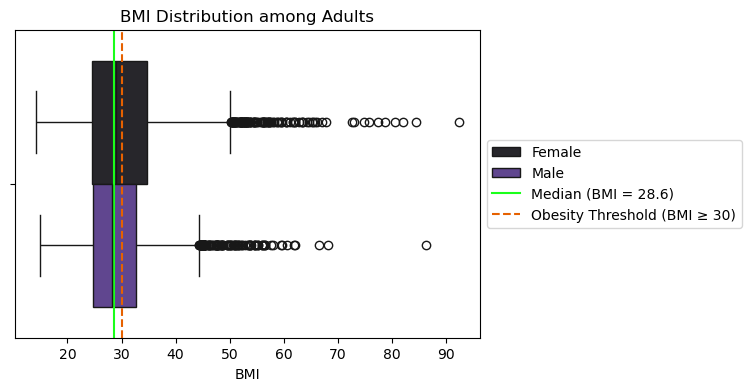

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x='bmi', data=adults_joined, color = '#5D3A9B', hue="gender_label")

# Calculate median
median_val = adults_joined['bmi'].median()

# Add vertical line for the median and include it in the legend
plt.axvline(median_val, color='#1AFF1A', linestyle='-', label=f"Median (BMI = {median_val:.1f})")

# Obesity threshold line
plt.axvline(30, color='#E66100', linestyle='--', label="Obesity Threshold (BMI ≥ 30)")

plt.title("BMI Distribution among Adults")
plt.xlabel("BMI")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

In this dataset, the average BMI for women is higher than that for men. This observation aligns with known physiological differences—specifically, the role of estrogen in promoting fat storage, which contributes to higher body fat percentages in women. The dataset has an approximately equal distribution of male and female subjects, so this difference is unlikely to be due to sampling bias.

However, there are notable outliers in the dataset, particularly individuals with a BMI greater than 50. Such high BMI values are rare in the general population and could disproportionately influence the results of the analysis. To assess their impact, the proportion of individuals with BMI over 50 was examined.

In [22]:
num_high_bmi = (adults_joined['bmi'] > 50).sum()
print(f"Number of subjects with BMI > 50: {num_high_bmi}")
prop_high_bmi = (adults_joined['bmi'] > 50).mean()
print(f"Proportion of subjects with BMI > 50: {prop_high_bmi:.2%}")

Number of subjects with BMI > 50: 168
Proportion of subjects with BMI > 50: 1.91%


It was found that less than 2% of the dataset falls into this category. Given this small proportion, and to reduce the influence of extreme outliers, the decision was made to restrict the analysis to subjects with a BMI of 50 or less.

In [23]:
adults_filtered = adults_joined[adults_joined['bmi'] <= 50].copy()

In [24]:
adults_filtered['bmi'].describe()

count    8622.000000
mean       29.357237
std         6.583851
min        14.200000
25%        24.600000
50%        28.500000
75%        33.300000
max        50.000000
Name: bmi, dtype: float64

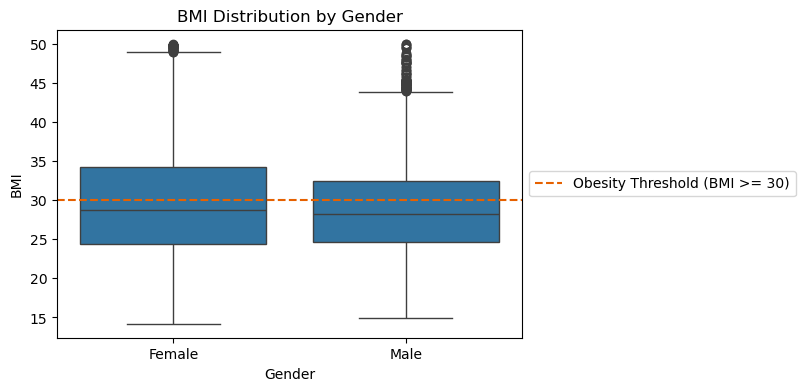

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x='gender_label',y='bmi',data=adults_filtered)

plt.axhline(30, color='#E66100',linestyle='--', label= "Obesity Threshold (BMI >= 30)")
plt.title("BMI Distribution by Gender")
plt.ylabel('BMI')
plt.xlabel('Gender')
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

In [26]:
gender = adults_filtered.groupby('gender')['bmi'].describe()
gender = gender.rename(index={1: "Male", 2:"Female"})
gender

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Male,4225.0,28.956615,5.970412,14.9,24.7,28.2,32.4,50.0
Female,4397.0,29.742188,7.103129,14.2,24.4,28.8,34.2,50.0


Even after removing outliers, the average BMI of the dataset still falls within the overweight range, reflecting overall trends in the U.S. population. The next step is to isolate subjects classified as obese (BMI ≥ 30) into a separate DataFrame for further analysis.

In [27]:
obese = adults_filtered[adults_filtered['bmi'] >= 30]

In [28]:
obese.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,standing_height,standing_height_comment,bmi,upper_leg_cm,upper_arm_cm,arm_circumference_cm,waist_circ_cm,hip_circ_cm,gender_label
0,109266.0,2.0,29.0,6.0,5.0,3.0,5.0,97.1,160.2,NaN,37.8,40.8,34.7,35.8,117.9,126.1,Female
3,109274.0,1.0,68.0,7.0,4.0,3.0,1.2,103.7,185.3,NaN,30.2,44.0,47.0,32.0,109.6,107.8,Male
5,109284.0,2.0,44.0,1.0,2.0,1.0,NaN,91.1,152.7,NaN,39.1,33.0,33.5,38.5,103.1,125.5,Female
8,109291.0,2.0,42.0,6.0,5.0,1.0,NaN,81.4,161.3,NaN,31.3,NaN,NaN,NaN,NaN,NaN,Female
9,109292.0,1.0,58.0,2.0,3.0,2.0,1.6,86.0,167.8,NaN,30.5,38.4,39.5,29.0,108.3,106.4,Male


## Urine Albumin

The first urine biomarker analyzed in relation to BMI is urine albumin, a key indicator of kidney function. Elevated urinary albumin excretion suggests renal damage, making it an important factor in assessing metabolic health.

There are two primary collection methods for urinary biomarkers: 24-hour urine collection and spot testing. NHANES utilizes the latter, which measures urine albumin and creatinine from single void samples.

In the NHANES dataset, urine albumin values labeled as “< LOD” (below the limit of detection) or “>1000 µg/mL” are flagged as outliers. For this analysis, the normal reference range was defined as <30 µg/mL, based on Jones et al. (Am J Kidney Dis., 2002; 39:445–459).

To ensure consistency, only columns reporting values in µg/mL were retained for further analysis.

In [29]:
df_cralb = pd.read_csv('urine_cr_alb.csv')

In [30]:
urine_cralb = obese.merge(df_cralb, on='participant_id')

In [31]:
adults_cralb = adults_joined.merge(df_cralb, on='participant_id')

In [32]:
urine_cralb.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,standing_height,standing_height_comment,...,gender_label,Unnamed: 0,albumin_urine_ug_mL,albumin_urine_mg_L,alb_comment,creatinine_urine_mg_dL,creatinine_urine_umol_L,creatinine_comment,alb_creat_ratio,collection_year
0,109266.0,2.0,29.0,6.0,5.0,3.0,5.00,97.1,160.2,NaN,...,Female,1,5.5,5.5,0.0,36.0,3182.4,0.0,15.28,2017-2020
1,109274.0,1.0,68.0,7.0,4.0,3.0,1.20,103.7,185.3,NaN,...,Male,5,12.8,12.8,0.0,120.0,10608.0,0.0,10.67,2017-2020
2,109284.0,2.0,44.0,1.0,2.0,1.0,NaN,91.1,152.7,NaN,...,Female,11,8.2,8.2,0.0,189.0,16707.6,0.0,4.34,2017-2020
3,109291.0,2.0,42.0,6.0,5.0,1.0,NaN,81.4,161.3,NaN,...,Female,17,16.4,16.4,0.0,261.0,23072.4,0.0,6.28,2017-2020
4,109293.0,1.0,44.0,3.0,3.0,3.0,0.02,99.4,181.6,NaN,...,Male,19,7.2,7.2,0.0,57.0,5038.8,0.0,12.63,2017-2020


In [33]:
urine_cralb.shape

(3448, 26)

In [34]:
urine_cralb.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'education_level',
       'marital_status', 'family_income_poverty', 'weight_kg',
       'standing_height', 'standing_height_comment', 'bmi', 'upper_leg_cm',
       'upper_arm_cm', 'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm',
       'gender_label', 'Unnamed: 0', 'albumin_urine_ug_mL',
       'albumin_urine_mg_L', 'alb_comment', 'creatinine_urine_mg_dL',
       'creatinine_urine_umol_L', 'creatinine_comment', 'alb_creat_ratio',
       'collection_year'],
      dtype='object')

In [35]:
urine_cralb = urine_cralb[['participant_id','gender','age_year','gender_label','bmi',
'albumin_urine_ug_mL', 'creatinine_urine_mg_dL','alb_creat_ratio']]

In [36]:
urine_cralb.isna().sum()

participant_id            0
gender                    0
age_year                  0
gender_label              0
bmi                       0
albumin_urine_ug_mL       0
creatinine_urine_mg_dL    0
alb_creat_ratio           0
dtype: int64

With the initial data cleaning, the NaN values have been removed. 

In [37]:
urine_cralb.describe(include='all')

,participant_id,gender,age_year,gender_label,bmi,albumin_urine_ug_mL,creatinine_urine_mg_dL,alb_creat_ratio
count,3448.000000,3448.000000,3448.000000,3448,3448.000000,3448.000000,3448.000000,3448.000000
unique,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Female,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,1880,NaN,NaN,NaN,NaN
mean,117062.047564,1.545244,49.816995,NaN,35.782570,63.937558,142.477378,57.838222
std,4564.177792,0.498021,17.155913,NaN,4.709608,405.712906,88.483911,371.666530
min,109266.000000,1.000000,18.000000,NaN,30.000000,0.300000,8.000000,0.860000
25%,113031.000000,1.000000,36.000000,NaN,32.000000,5.500000,76.000000,4.960000
50%,116966.500000,2.000000,51.000000,NaN,34.600000,10.600000,126.500000,7.880000
75%,121099.500000,2.000000,63.000000,NaN,38.500000,22.800000,190.000000,16.122500


In [38]:
urine_alb = urine_cralb[['participant_id','gender','gender_label','age_year','bmi','albumin_urine_ug_mL', 'alb_creat_ratio']]

In [39]:
urine_alb['albumin_urine_ug_mL'].describe()

count     3448.000000
mean        63.937558
std        405.712906
min          0.300000
25%          5.500000
50%         10.600000
75%         22.800000
max      14040.000000
Name: albumin_urine_ug_mL, dtype: float64

Due to variability in how urine albumin ranges are interpreted, excluding outliers is not always appropriate. However, extremely high values—such as the entry near 14,000 µg/mL—fall well outside expected clinical ranges and are likely due to data entry or assay error.

In [40]:
urine_alb[urine_alb["albumin_urine_ug_mL"] >= 1000].describe()

,participant_id,gender,age_year,bmi,albumin_urine_ug_mL,alb_creat_ratio
count,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000
mean,116317.022727,1.431818,53.090909,36.984091,2555.250000,2242.461818
std,4864.374314,0.501056,14.289072,4.526765,2486.739353,2281.012418
min,109843.000000,1.000000,27.000000,30.700000,1019.000000,287.960000
25%,111411.750000,1.000000,43.000000,33.275000,1217.500000,828.830000
50%,115144.500000,1.000000,53.500000,36.550000,1675.500000,1437.390000
75%,120967.750000,2.000000,60.250000,40.325000,2322.500000,2372.220000
max,124464.000000,2.000000,80.000000,48.400000,14040.000000,11055.120000


In [41]:
# Define your threshold
threshold = 1000  

# Count how many subjects exceed the threshold
extreme_count = (urine_alb['albumin_urine_ug_mL'] >= threshold).sum()

# Total number of subjects
total_count = urine_alb['albumin_urine_ug_mL'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme albumin values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with albumin values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")


Subjects with extreme albumin values (≥ 1000 µg/mL): 44
Total subjects with albumin values: 3448
Percentage extreme: 1.28%


To explore potential associations between elevated urine albumin and BMI, subjects with albumin levels ≥1000 µg/mL were briefly examined. Although this subgroup exhibits a wide range of BMI values, its mean BMI is higher than that of the overall cohort. This group may warrant further investigation; however, because it represents only a small proportion of the total sample, these subjects were excluded to maintain a more representative dataset for downstream analyses.

In [42]:
# Define threshold
threshold = 1000  

# Keep only subjects below threshold
urine_alb_clean = urine_alb[urine_alb['albumin_urine_ug_mL'] < threshold].copy()

print(f"Original: {urine_alb.shape[0]} rows")
print(f"After removing extreme albumin values: {urine_alb_clean.shape[0]} rows")

Original: 3448 rows
After removing extreme albumin values: 3404 rows


In [43]:
urine_alb_clean.describe(include='all')

,participant_id,gender,gender_label,age_year,bmi,albumin_urine_ug_mL,alb_creat_ratio
count,3404.000000,3404.000000,3404,3404.000000,3404.000000,3404.000000,3404.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN
top,NaN,NaN,Female,NaN,NaN,NaN,NaN
freq,NaN,NaN,1861,NaN,NaN,NaN,NaN
mean,117071.677732,1.546710,NaN,49.774677,35.767039,31.734929,29.599844
std,4560.132234,0.497887,NaN,17.187512,4.710558,85.467464,108.033424
min,109266.000000,1.000000,NaN,18.000000,30.000000,0.300000,0.860000
25%,113050.500000,1.000000,NaN,36.000000,32.000000,5.400000,4.930000
50%,116979.500000,2.000000,NaN,50.000000,34.600000,10.400000,7.800000
75%,121101.750000,2.000000,NaN,63.000000,38.500000,21.825000,15.655000


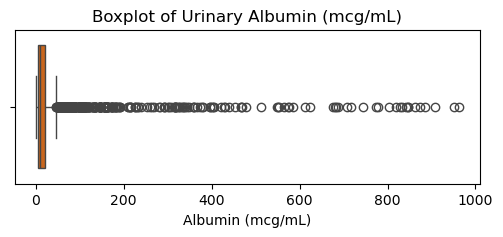

In [44]:
plt.figure(figsize=(6,2))
sns.boxplot(x=urine_alb_clean['albumin_urine_ug_mL'], color='#E66100')
plt.title("Boxplot of Urinary Albumin (mcg/mL)")
plt.xlabel("Albumin (mcg/mL)")
plt.show()

With the outliers removed, the average value of the urine albumin is 31 mcg/mL which is about the reference range from the NHANES study. 

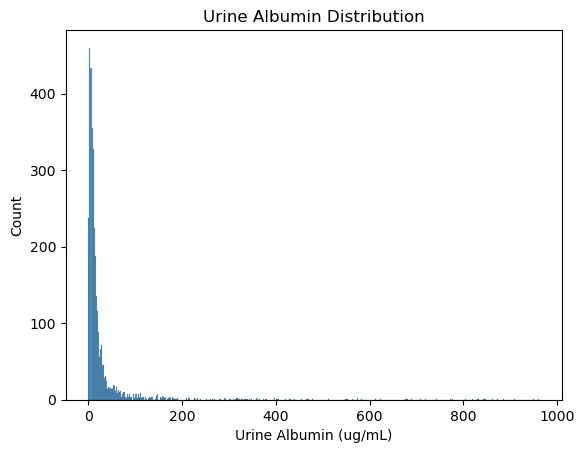

In [45]:
sns.histplot(data=urine_alb_clean, x="albumin_urine_ug_mL")
plt.title('Urine Albumin Distribution')
plt.xlabel('Urine Albumin (ug/mL)')
plt.show()

As most lab values are, the urine albumin is also right skewed like the BMI. Because the BMI and lab values are not normally distributed, Pearson correlation may not be the most appropriate method to assess for the relationship. Spearman's rank test was used to find the correlation between the BMI and urine albumin levels.

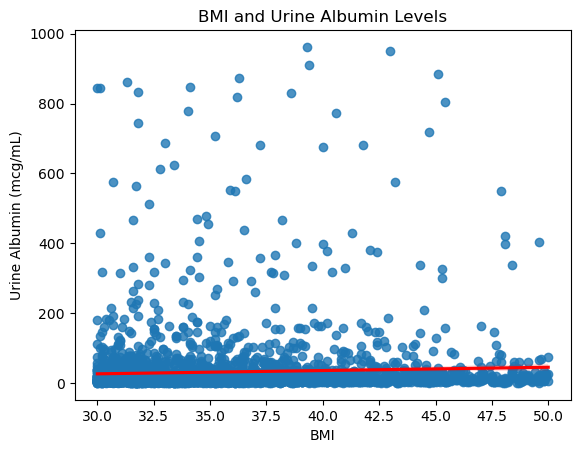

In [46]:
sns.regplot(x='bmi',y='albumin_urine_ug_mL',data=urine_alb_clean,line_kws={"color": "red"})
plt.xlabel('BMI')
plt.ylabel('Urine Albumin (mcg/mL)')
plt.title('BMI and Urine Albumin Levels')
plt.show()

In [47]:
slope, intercept, r_value, p_value, std_err = linregress(urine_alb_clean['bmi'], urine_alb_clean['albumin_urine_ug_mL'])

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")

Slope: 0.9430
Intercept: -1.9927
R-squared: 0.0027
P-value: 2.4196e-03


In [1]:
corr = urine_alb_clean[['bmi', 'albumin_urine_ug_mL']].corr(method='spearman').iloc[0, 1]
print(f"Spearman rank correlation between BMI and urine albumin: {corr:.3f}")

NameError: name 'urine_alb_clean' is not defined

The regression plot of the BMI vs Urine Albumin levels shows a pretty flat line. There does not seem to be an overt linear correlation between those two categories. Further statistical analysis shows that the slope of the regression line is 0.94 which is a very small value. The correlation coefficient of those two values shows 0.052 which is statistically insignificant.

Although the Spearman's correlation value is slightly higher at 0.088, it still remains statistically insignificant.

Without the log transformation/normalization of the data points, the correlation appears weak/nonexistent. Would transforming the data have any significant impact? The next step is to see how natural log transformation of the data impacts the correlation.

#### Log Transformation of the Albumin Labs

In [49]:
urine_alb_clean['log_ualb'] = np.log(urine_alb_clean['albumin_urine_ug_mL'])

In [50]:
urine_alb_clean[['albumin_urine_ug_mL', 'log_ualb']].describe()

,albumin_urine_ug_mL,log_ualb
count,3404.000000,3404.000000
mean,31.734929,2.471974
std,85.467464,1.210709
min,0.300000,-1.203973
25%,5.400000,1.686399
50%,10.400000,2.341806
75%,21.825000,3.083054
max,962.000000,6.869014


In [51]:
urine_alb_clean['albumin_urine_ug_mL'].skew(), urine_alb_clean['log_ualb'].skew()

#greater the value, the more skewed the dataset is. After the natural log transformation, the data is no longer skewed

(np.float64(6.640408718289633), np.float64(0.6914366658026331))

In [52]:
urine_alb_clean['albumin_urine_ug_mL'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


0.25      5.400
0.50     10.400
0.75     21.825
0.90     57.400
0.95    114.375
0.99    466.970
Name: albumin_urine_ug_mL, dtype: float64

In [53]:
urine_alb_clean['log_ualb'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    1.686399
0.50    2.341806
0.75    3.083054
0.90    4.050044
0.95    4.739471
0.99    6.146265
Name: log_ualb, dtype: float64

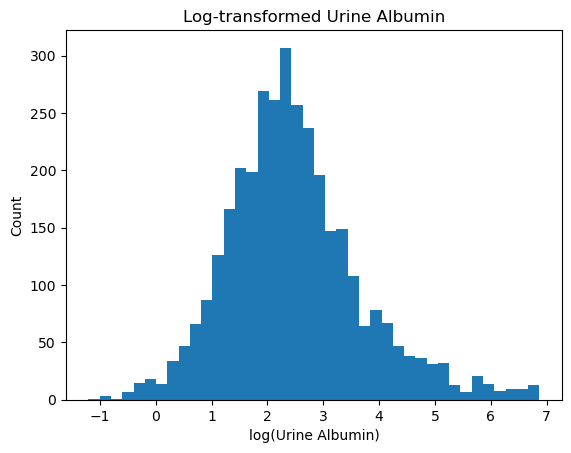

In [54]:
plt.hist(urine_alb_clean['log_ualb'].dropna(), bins=40)
plt.title("Log-transformed Urine Albumin")
plt.xlabel("log(Urine Albumin)")
plt.ylabel("Count")
plt.show()

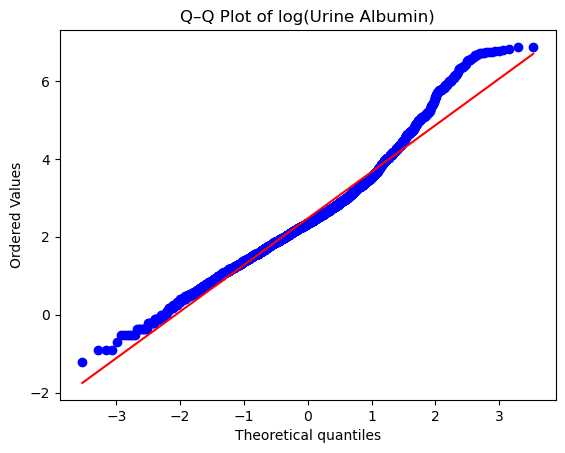

In [55]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(urine_alb_clean['log_ualb'], dist="norm", plot=plt)
plt.title("Q–Q Plot of log(Urine Albumin)")
plt.show()


In [56]:
urine_alb_clean[['bmi','log_ualb']].corr()

,bmi,log_ualb
bmi,1.000000,0.085796
log_ualb,0.085796,1.000000


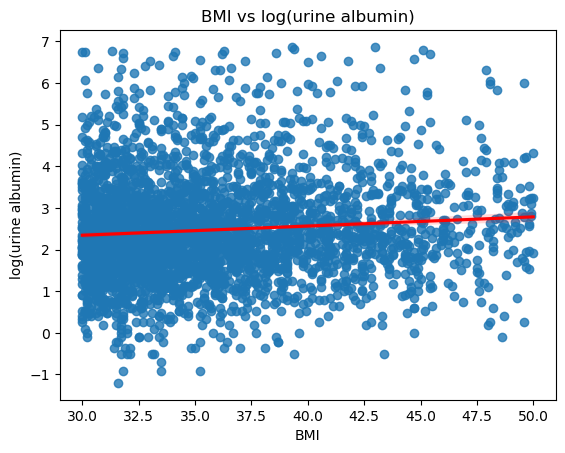

In [57]:
sns.regplot(x='bmi',y='log_ualb',data=urine_alb_clean,line_kws={"color": "red"})
plt.xlabel("BMI")
plt.ylabel("log(urine albumin)")
plt.title("BMI vs log(urine albumin)")
plt.show()

Even with normalization, there is no significant correlation between BMI and urine albumin lab results.

### Gender

The correlation between BMI and urine albumin is basically none. The next step is to separate the two genders and see if there is any correlation with BMI with regards to gender. 

The normal urine albumin range does differ a bit between the two genders. Females are expected to have a slightly higher average compares to males (<25 mcg/mL vs <17 mcg/mL). 

In [58]:
albumin_stats = urine_alb_clean.groupby("gender_label")["albumin_urine_ug_mL"].describe()
print(albumin_stats)

               count       mean        std  min   25%   50%   75%    max
gender_label                                                            
Female        1861.0  28.079688  77.012953  0.3  5.20  10.1  20.9  962.0
Male          1543.0  36.143487  94.503095  0.4  5.65  10.7  23.7  885.0


There are more females compared to the males in the data set. There are 318 more females than males. 

(0.0, 150.0)

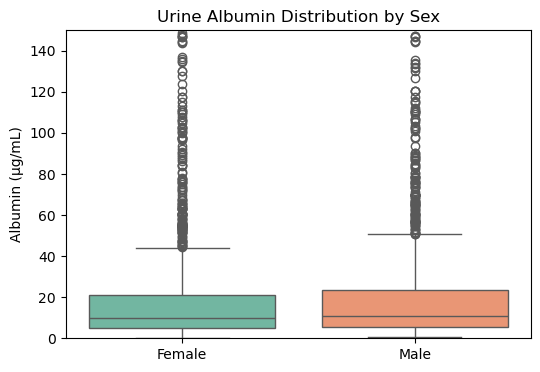

In [59]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender_label", y="albumin_urine_ug_mL", data=urine_alb_clean, palette="Set2")
plt.title("Urine Albumin Distribution by Sex")
plt.xlabel("")
plt.ylabel("Albumin (µg/mL)")
plt.ylim(0,150)

Separation and grouping the data by gender does not seem to change the median value of the urine albumin by much. 

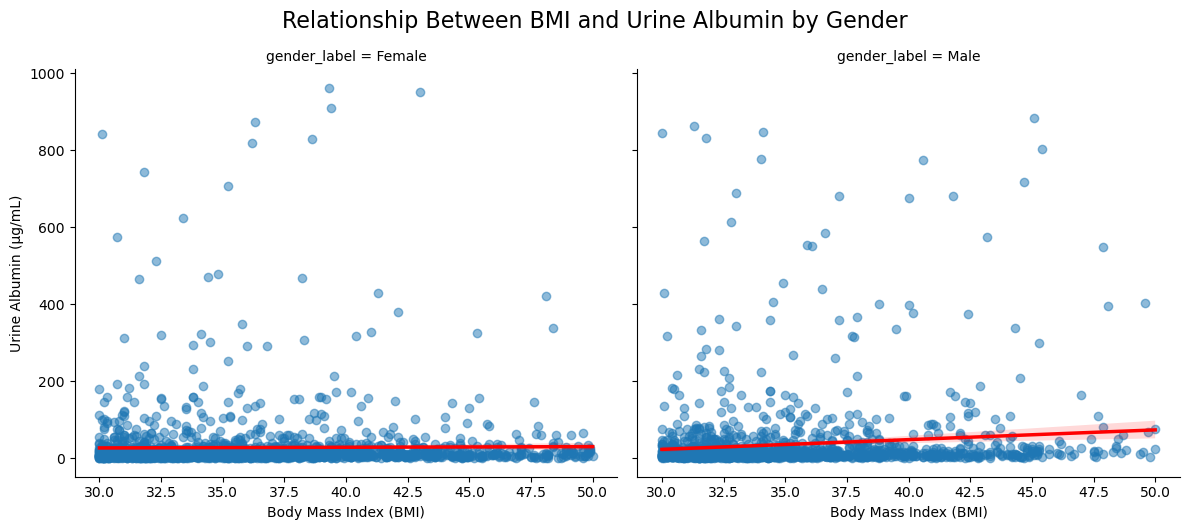

In [60]:
# Plot
g = sns.lmplot(
    x="bmi",
    y="albumin_urine_ug_mL",
    col="gender_label",  # use the new label column
    data=urine_alb_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "linewidth": 2.5}
)

# Add an overall title
g.fig.suptitle("Relationship Between BMI and Urine Albumin by Gender", fontsize=16, y=1.05)

# Add axis labels
g.set_axis_labels("Body Mass Index (BMI)", "Urine Albumin (µg/mL)")

plt.show()

In [61]:
# Loop over genders
for sex in urine_alb_clean['gender_label'].unique():
    subset = urine_alb_clean[urine_alb_clean['gender_label'] == sex]
    slope, intercept, r_value, p_value, std_err = linregress(subset['bmi'], subset['albumin_urine_ug_mL'])
    print(f"{sex}: slope={slope:.4f}, intercept={intercept:.2f}, r={r_value:.4f}, p={p_value:.4g}")

Female: slope=0.1693, intercept=21.93, r=0.0109, p=0.6378
Male: slope=2.5274, intercept=-52.58, r=0.1147, p=6.291e-06


In [62]:
for gender, df_group in urine_alb_clean.groupby('gender_label'):
    corr = df_group[['bmi', 'albumin_urine_ug_mL']].corr().iloc[0, 1]
    print(f"Pearson correlation between BMI and urine albumin for {gender}: {corr:.3f}")

for gender, df_group in urine_alb_clean.groupby('gender_label'):
    corr = df_group[['bmi', 'albumin_urine_ug_mL']].corr(method="spearman").iloc[0, 1]
    print(f"Spearman's rank correlation between BMI and urine albumin for {gender}: {corr:.3f}")

Pearson correlation between BMI and urine albumin for Female: 0.011
Pearson correlation between BMI and urine albumin for Male: 0.115
Spearman's rank correlation between BMI and urine albumin for Female: 0.061
Spearman's rank correlation between BMI and urine albumin for Male: 0.134


The regression lines and their respective slopes suggest only a weak relationship between BMI and urine albumin levels. While the slope is steeper in males (2.52) than in females (0.16), this difference does not translate to a meaningful correlation. The calculated correlation coefficients were 0.115 for males and 0.011 for females—both very low.

Although the male cohort shows a slightly greater tendency toward higher urine albumin levels with increasing BMI, the strength of this association is minimal and unlikely to be statistically significant.

#### Log transformation

In [63]:
albumin_log = urine_alb_clean.groupby("gender_label")["log_ualb"].describe()
print(albumin_log)

               count      mean       std       min       25%       50%  \
gender_label                                                             
Female        1861.0  2.408318  1.184727 -1.203973  1.648659  2.312535   
Male          1543.0  2.548749  1.237358 -0.916291  1.731616  2.370244   

                   75%       max  
gender_label                      
Female        3.039749  6.869014  
Male          3.165466  6.785588  


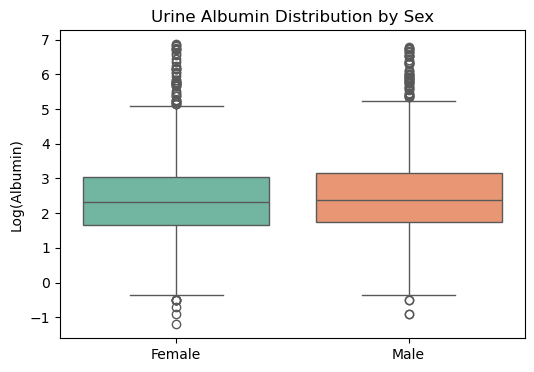

In [64]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender_label", y="log_ualb", data=urine_alb_clean, palette="Set2")
plt.title("Urine Albumin Distribution by Sex")
plt.xlabel("")
plt.ylabel("Log(Albumin)")
plt.show()

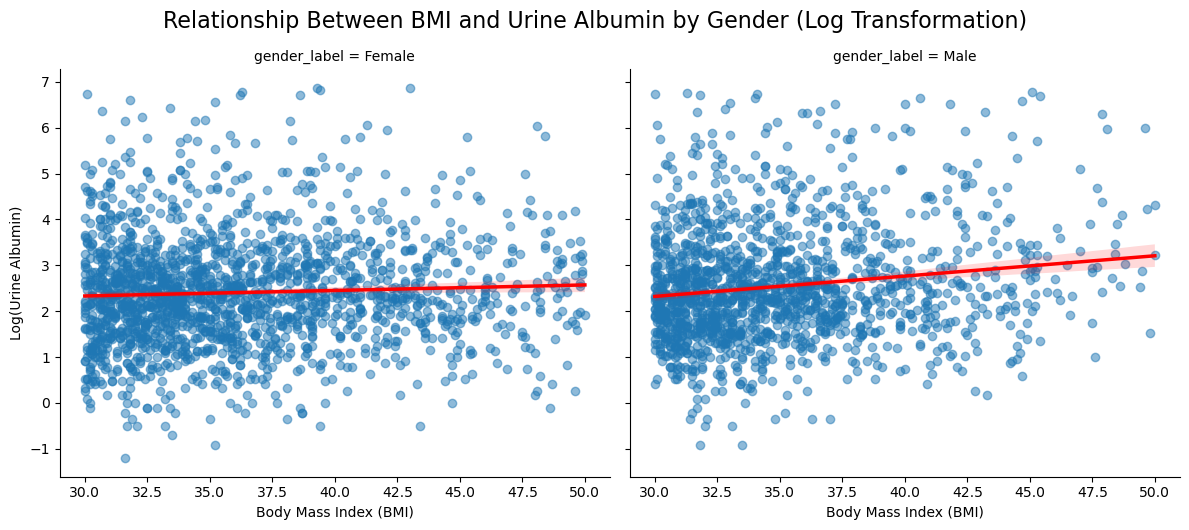

In [65]:
# Plot
g_log = sns.lmplot(
    x="bmi",
    y="log_ualb",
    col="gender_label",  # use the new label column
    data=urine_alb_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "linewidth": 2.5}
)

# Add an overall title
g_log.fig.suptitle("Relationship Between BMI and Urine Albumin by Gender (Log Transformation)", fontsize=16, y=1.05)

# Add axis labels
g_log.set_axis_labels("Body Mass Index (BMI)", "Log(Urine Albumin)")

plt.show()

In [66]:
# Loop over genders
for sex in urine_alb_clean['gender_label'].unique():
    subset_log = urine_alb_clean[urine_alb_clean['gender_label'] == sex]
    slope, intercept, r_value, p_value, std_err = linregress(subset_log['bmi'], subset_log['log_ualb'])
    print(f"{sex}: slope={slope:.4f}, intercept={intercept:.2f}, r={r_value:.4f}, p={p_value:.4g}")

Female: slope=0.0120, intercept=1.97, r=0.0505, p=0.02944
Male: slope=0.0443, intercept=0.99, r=0.1535, p=1.357e-09


In [67]:
for gender, df_group in urine_alb_clean.groupby('gender_label'):
    corr_log = df_group[['bmi', 'log_ualb']].corr().iloc[0, 1]
    print(f"Pearson correlation between BMI and urine albumin for {gender}: {corr_log:.3f}")

Pearson correlation between BMI and urine albumin for Female: 0.050
Pearson correlation between BMI and urine albumin for Male: 0.153


In [68]:
import numpy as np
from math import atanh, sqrt

# Split groups
male = urine_alb_clean[urine_alb_clean['gender_label'] == 'Male']
female = urine_alb_clean[urine_alb_clean['gender_label'] == 'Female']

# Correlations
r_m = male['bmi'].corr(male['log_ualb'])
r_f = female['bmi'].corr(female['log_ualb'])

# Sample sizes
n_m = len(male)
n_f = len(female)

# Fisher r-to-z transformation
z_m = atanh(r_m)
z_f = atanh(r_f)

# Standard error
se = sqrt(1/(n_m - 3) + 1/(n_f - 3))

# z-test statistic
z = (z_m - z_f) / se

z

3.0236405959890886

In [69]:
from math import erf, sqrt

p_value = 2 * (1 - 0.5 * (1 + erf(abs(3.02) / sqrt(2))))
p_value


0.002527746855344626

After normalizing the urine albumin data, the correlation seen between sexes is more significant. There is a weak correlation between the BMI and urine albumin values in males whereas there is no correlation for females. 

## Urine Creatinine

Creatinine is a byproduct that is created when skeletal mucles are metabolized or breaking down of ingested meat products. It is another biomarker that can show the kidney function, with elevated creatinine as renal damage and also shows their fluid balance. 

According to the laboratory test that was performed for the purposes of NHANES, the normal range for urine creatinine is as reported as follows:

 * Urine, adult male, first morning void: 40-278 mg/dL
 * Urine, adult female, first morning void: 29-226 mg/dL

(Mazzachi, et al. From the Roche reagent package insert for enzymatic creatinine.)

In [70]:
urine_cr = urine_cralb[['participant_id','gender','gender_label','age_year','bmi',
'creatinine_urine_mg_dL']]

In [71]:
urine_cr.describe(include='all')

,participant_id,gender,gender_label,age_year,bmi,creatinine_urine_mg_dL
count,3448.000000,3448.000000,3448,3448.000000,3448.000000,3448.000000
unique,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,Female,NaN,NaN,NaN
freq,NaN,NaN,1880,NaN,NaN,NaN
mean,117062.047564,1.545244,NaN,49.816995,35.782570,142.477378
std,4564.177792,0.498021,NaN,17.155913,4.709608,88.483911
min,109266.000000,1.000000,NaN,18.000000,30.000000,8.000000
25%,113031.000000,1.000000,NaN,36.000000,32.000000,76.000000
50%,116966.500000,2.000000,NaN,51.000000,34.600000,126.500000
75%,121099.500000,2.000000,NaN,63.000000,38.500000,190.000000


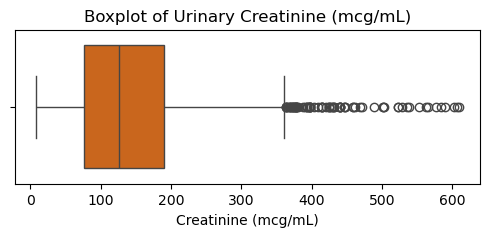

In [72]:
plt.figure(figsize=(6,2))
sns.boxplot(x=urine_cr['creatinine_urine_mg_dL'], color='#E66100')
plt.title("Boxplot of Urinary Creatinine (mcg/mL)")
plt.xlabel("Creatinine (mcg/mL)")
plt.show()

The overall average urine creatinine concentration was 142.47 mg/dL. Unlike urine albumin, there is no universally defined normal range for urine creatinine. Instead, reference values differ by sex; therefore, the analysis was stratified by gender from the outset.

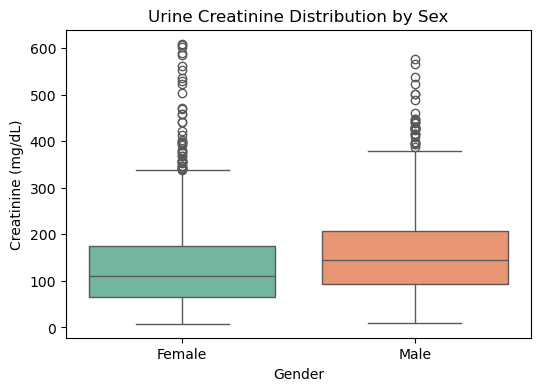

In [73]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender_label", y="creatinine_urine_mg_dL", data=urine_cr, palette="Set2")
plt.title("Urine Creatinine Distribution by Sex")
plt.ylabel("Creatinine (mg/dL)")
plt.xlabel("Gender")
plt.show()

There are some outliers but it apperas that most of these values fall within the normal range as specified above. The decision was made to keep all of these values, as the outliers do not seem to be skewing the data too much. 

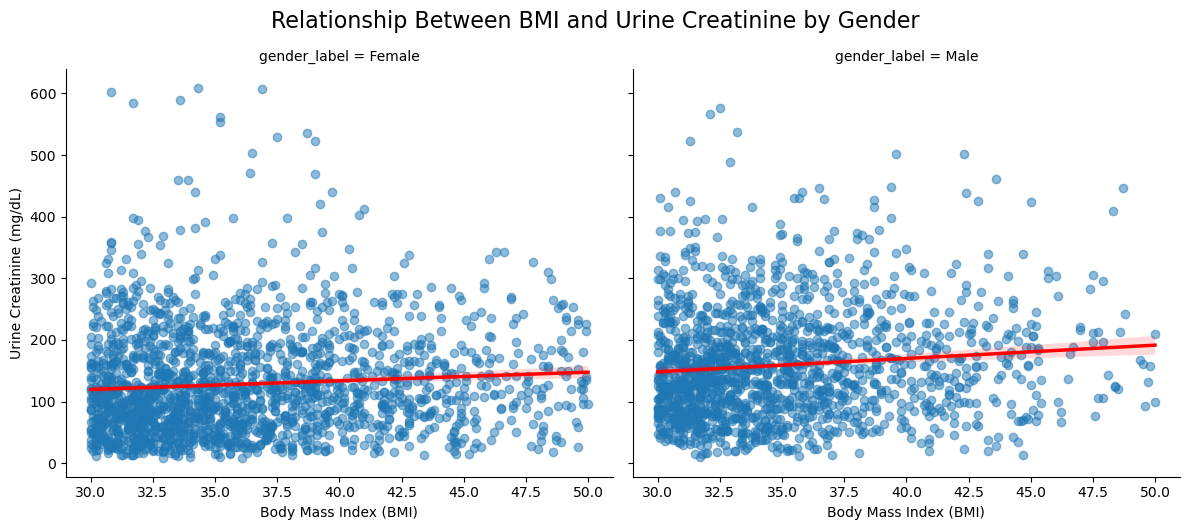

In [74]:
# Plot
g = sns.lmplot(
    x="bmi",
    y="creatinine_urine_mg_dL",
    col="gender_label",  # use the new label column
    data=urine_cr,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "linewidth": 2.5}
)

# Add an overall title
g.fig.suptitle("Relationship Between BMI and Urine Creatinine by Gender", fontsize=16, y=1.05)

# Add axis labels
g.set_axis_labels("Body Mass Index (BMI)", "Urine Creatinine (mg/dL)")

plt.show()

The linear regression line does not seem to have a strong slope or correlation. Male subjects seem to have a slightly stronger positive correlation compared to the female subjects but both lines' slopes seem to be minimal. 

In [75]:
for gender, df_group in urine_cr.groupby('gender_label'):
    corr = df_group[['bmi', 'creatinine_urine_mg_dL']].corr().iloc[0, 1]
    print(f"Correlation between BMI and urine creatinine for {gender}: {corr:.3f}")

Correlation between BMI and urine creatinine for Female: 0.081
Correlation between BMI and urine creatinine for Male: 0.105


Between the two genders, again the male sex seems to have a miniscule correlation between the urine creatinine and BMI. The female urine creatinine correlation with BMI is negligible. 

#### Log Transformation of Urine Creatinine

In [76]:
urine_cr['log_ucr'] = np.log(urine_cr['creatinine_urine_mg_dL'])

In [77]:
urine_cr[['creatinine_urine_mg_dL', 'log_ucr']].describe()

,creatinine_urine_mg_dL,log_ucr
count,3448.000000,3448.000000
mean,142.477378,4.748777
std,88.483911,0.696061
min,8.000000,2.079442
25%,76.000000,4.330733
50%,126.500000,4.840234
75%,190.000000,5.247024
max,609.000000,6.411818


In [78]:
urine_cr['creatinine_urine_mg_dL'].skew(), urine_cr['log_ucr'].skew()

(np.float64(1.20040133322721), np.float64(-0.6309526932114464))

In [79]:
urine_cr['creatinine_urine_mg_dL'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25     76.00
0.50    126.50
0.75    190.00
0.90    259.30
0.95    303.65
0.99    428.06
Name: creatinine_urine_mg_dL, dtype: float64

In [80]:
urine_cr['log_ucr'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    4.330733
0.50    4.840234
0.75    5.247024
0.90    5.557984
0.95    5.715874
0.99    6.059261
Name: log_ucr, dtype: float64

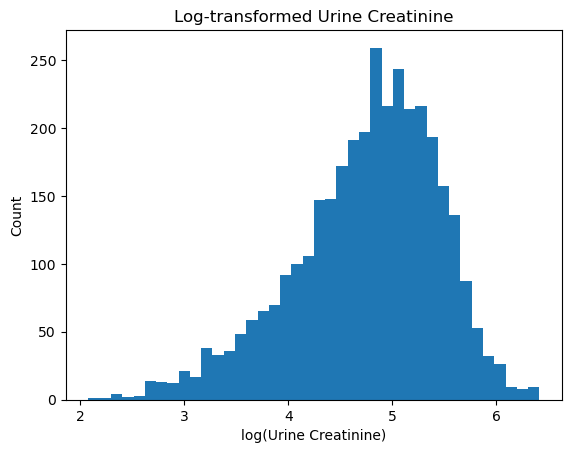

In [81]:
plt.hist(urine_cr['log_ucr'], bins=40)
plt.title("Log-transformed Urine Creatinine")
plt.xlabel("log(Urine Creatinine)")
plt.ylabel("Count")
plt.show()

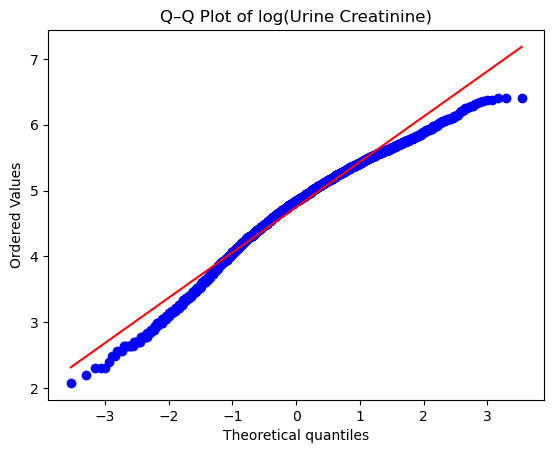

In [82]:
stats.probplot(urine_cr['log_ucr'], dist="norm", plot=plt)
plt.title("Q–Q Plot of log(Urine Creatinine)")
plt.show()

In [83]:
urine_cr[['bmi','log_ucr']].corr()

,bmi,log_ucr
bmi,1.000000,0.077376
log_ucr,0.077376,1.000000


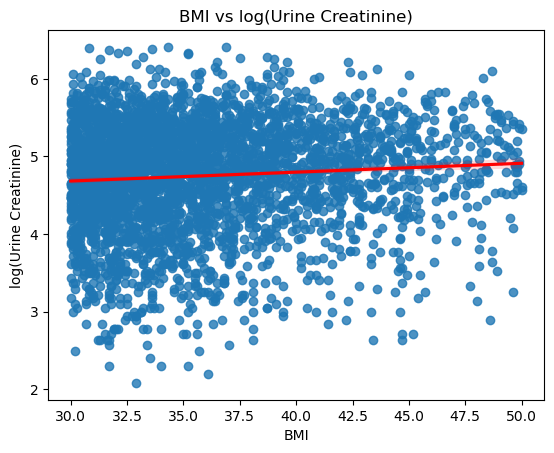

In [84]:
sns.regplot(x='bmi',y='log_ucr',data=urine_cr,line_kws={"color": "red"})
plt.xlabel("BMI")
plt.ylabel("log(Urine Creatinine)")
plt.title("BMI vs log(Urine Creatinine)")
plt.show()

**Log(Urine Creatinine) by Gender**

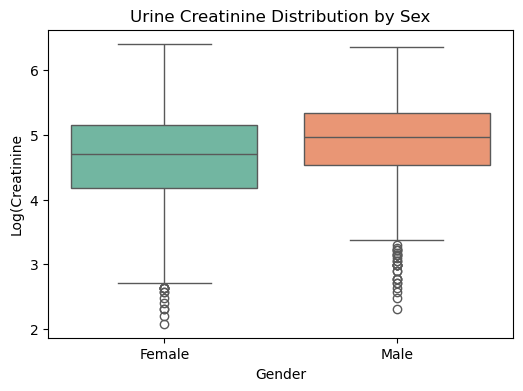

In [85]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender_label", y="log_ucr", data=urine_cr, palette="Set2")
plt.title("Urine Creatinine Distribution by Sex")
plt.ylabel("Log(Creatinine")
plt.xlabel("Gender")
plt.show()

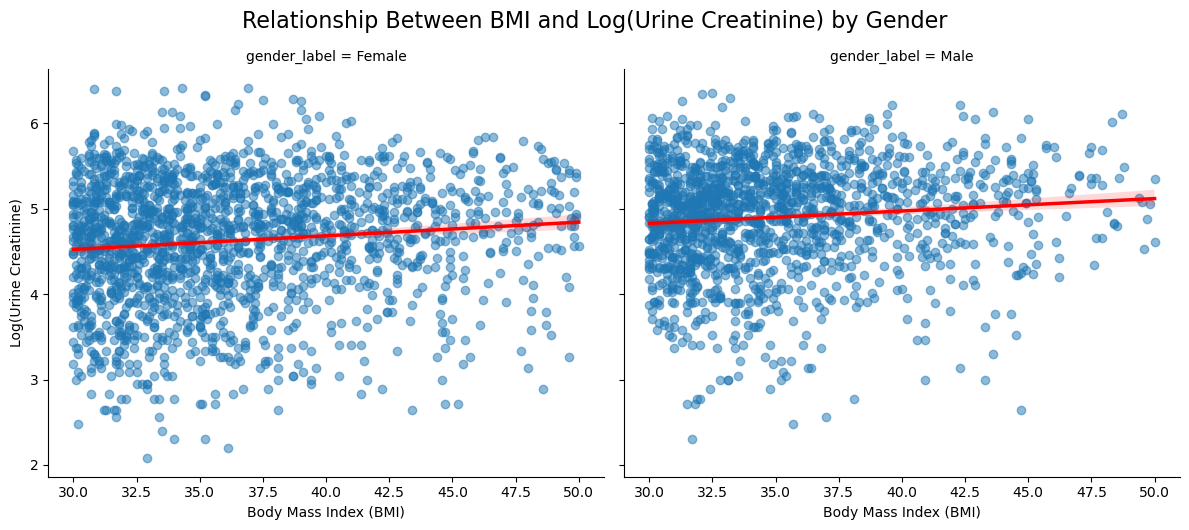

In [86]:
# Plot
g = sns.lmplot(
    x="bmi",
    y="log_ucr",
    col="gender_label",  # use the new label column
    data=urine_cr,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "linewidth": 2.5}
)

# Add an overall title
g.fig.suptitle("Relationship Between BMI and Log(Urine Creatinine) by Gender", fontsize=16, y=1.05)

# Add axis labels
g.set_axis_labels("Body Mass Index (BMI)", "Log(Urine Creatinine)")

plt.show()

In [87]:
for gender, df_group in urine_cr.groupby('gender_label'):
    corr_logcr = df_group[['bmi', 'log_ucr']].corr().iloc[0, 1]
    print(f"Correlation between BMI and urine creatinine for {gender}: {corr_logcr:.3f}")

Correlation between BMI and urine creatinine for Female: 0.109
Correlation between BMI and urine creatinine for Male: 0.100


## Urine Iodine

Iodine is necessary for thyroid function which contribute to the metabolism in the body. Urine iodine secretion 

Median urinary iodine concentrations:
* 100–199 mcg/L in children and adults
* 150–249 mcg/L in pregnant women
* greater than 100 mcg/L in lactating women
  
indicate iodine intakes are adequate (https://ods.od.nih.gov/factsheets/Iodine-HealthProfessional/#:~:text=The%20iodine%2Dreplete%20healthy%20adult,intakes%20are%20adequate%20%5B3%5D.)

In [88]:
iodine = pd.read_csv('cleaned_u_iodine.csv')

In [89]:
urine_iodine = obese.merge(iodine, on='participant_id')

In [90]:
urine_iodine.shape

(1119, 19)

After joining the tables on `participant_id`, the total number of rows/subjects left is 1119. 

Is there a way to calculate for power? 
Lab results are not normalized so it will have to use non-parametric statistical tests. 

In [91]:
urine_iodine.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,standing_height,standing_height_comment,bmi,upper_leg_cm,upper_arm_cm,arm_circumference_cm,waist_circ_cm,hip_circ_cm,gender_label,urine_iodine,urine_iodine_comment
0,109266.0,2.0,29.0,6.0,5.0,3.0,5.00,97.1,160.2,NaN,37.8,40.8,34.7,35.8,117.9,126.1,Female,50.6,0.0
1,109274.0,1.0,68.0,7.0,4.0,3.0,1.20,103.7,185.3,NaN,30.2,44.0,47.0,32.0,109.6,107.8,Male,265.3,0.0
2,109316.0,2.0,62.0,4.0,3.0,2.0,0.07,77.2,159.2,NaN,30.5,40.5,38.5,35.7,97.5,102.0,Female,80.1,0.0
3,109317.0,2.0,28.0,4.0,4.0,3.0,NaN,91.6,174.5,NaN,30.1,45.9,36.1,35.2,100.3,121.3,Female,117.1,0.0
4,109321.0,2.0,19.0,4.0,NaN,NaN,0.06,83.5,158.7,NaN,33.2,39.9,36.6,34.5,96.7,114.4,Female,301.6,0.0


In [92]:
urine_iodine = urine_iodine[['participant_id','gender', 'bmi','urine_iodine']]

In [93]:
urine_iodine.head()

,participant_id,gender,bmi,urine_iodine
0,109266.0,2.0,37.8,50.6
1,109274.0,1.0,30.2,265.3
2,109316.0,2.0,30.5,80.1
3,109317.0,2.0,30.1,117.1
4,109321.0,2.0,33.2,301.6


In [94]:
urine_iodine.describe()

,participant_id,gender,bmi,urine_iodine
count,1119.000000,1119.000000,1119.000000,1119.000000
mean,116989.534406,1.545130,35.746202,244.438159
std,4589.640141,0.498182,4.711354,719.650714
min,109266.000000,1.000000,30.000000,10.200000
25%,112942.000000,1.000000,31.950000,75.950000
50%,116993.000000,2.000000,34.600000,131.300000
75%,121013.500000,2.000000,38.300000,248.650000
max,124794.000000,2.000000,50.000000,17426.300000


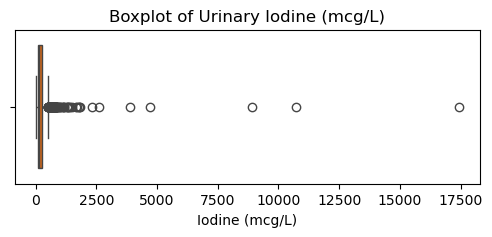

In [95]:
plt.figure(figsize=(6,2))
sns.boxplot(x=urine_iodine['urine_iodine'], color='#E66100')
plt.title("Boxplot of Urinary Iodine (mcg/L)")
plt.xlabel("Iodine (mcg/L)")
plt.show()

The urine iodine values are measured in micrograms per liter (mcg/L). In this dataset, several values exceed 10,000 mcg/L, which appears excessively high. Clinically, low urinary iodine concentrations are of greater concern, as they may indicate inadequate iodine intake needed for normal physiological function. However, the upper extremes observed in this cohort suggest potential outliers. Based on both descriptive statistics and visual inspection, applying an upper cutoff of 2,500 mcg/L is appropriate to exclude implausible values and enable a more accurate analysis.

In [96]:
# Define your threshold
threshold = 2500  

# Count how many subjects exceed the threshold
extreme_count = (urine_iodine['urine_iodine'] >= threshold).sum()

# Total number of subjects
total_count = urine_iodine['urine_iodine'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme iodine values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with iodine values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")

Subjects with extreme iodine values (≥ 2500 µg/mL): 6
Total subjects with iodine values: 1119
Percentage extreme: 0.54%


In [97]:
# Keep only subjects below threshold
urine_iodine_clean = urine_iodine[urine_iodine['urine_iodine'] < threshold].copy()

print(f"Original: {urine_iodine.shape[0]} rows")
print(f"After removing extreme albumin values: {urine_iodine_clean.shape[0]} rows")


Original: 1119 rows
After removing extreme albumin values: 1113 rows


In [98]:
urine_iodine_clean.describe()

,participant_id,gender,bmi,urine_iodine
count,1113.000000,1113.000000,1113.000000,1113.000000
mean,116982.694519,1.547170,35.748518,202.357682
std,4592.973628,0.497994,4.697845,227.592971
min,109266.000000,1.000000,30.000000,10.200000
25%,112929.000000,1.000000,32.000000,75.800000
50%,116963.000000,2.000000,34.600000,130.600000
75%,121041.000000,2.000000,38.300000,247.500000
max,124794.000000,2.000000,50.000000,2337.000000


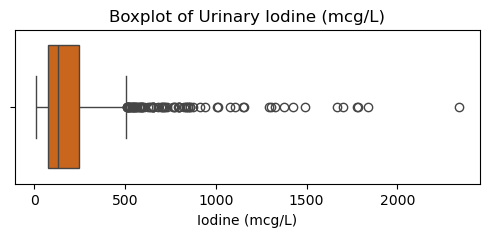

In [99]:
plt.figure(figsize=(6,2))
sns.boxplot(x=urine_iodine_clean['urine_iodine'], color='#E66100')
plt.title("Boxplot of Urinary Iodine (mcg/L)")
plt.xlabel("Iodine (mcg/L)")
plt.show()

After removing the values that are greather than or equal to 2500, the plot still shows quite a bit of variance and outliers. The decision was then made to limit the upper value of iodine to 1000 mcg/L.

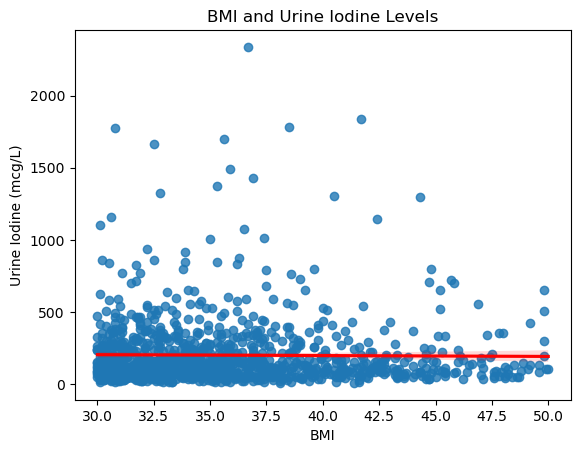

In [100]:
sns.regplot(x='bmi',y='urine_iodine',data=urine_iodine_clean,line_kws={"color": "red"})
plt.xlabel('BMI')
plt.ylabel('Urine Iodine (mcg/L)')
plt.title('BMI and Urine Iodine Levels')
plt.show()

In [101]:
slope, intercept, r_value, p_value, std_err = linregress(urine_iodine_clean['bmi'], 
                                                         urine_iodine_clean['urine_iodine'])

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")

Slope: -0.6097
Intercept: 224.1530
R-squared: 0.0002
P-value: 6.7493e-01


In [102]:
# Define your threshold
threshold = 1000 

# Count how many subjects exceed the threshold
extreme_count = (urine_iodine_clean['urine_iodine'] >= threshold).sum()

# Total number of subjects
total_count = urine_iodine_clean['urine_iodine'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme iodine values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with iodine values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")

Subjects with extreme iodine values (≥ 1000 µg/mL): 18
Total subjects with iodine values: 1113
Percentage extreme: 1.62%


In [103]:
# Keep only subjects below threshold
urine_iodine_clean = urine_iodine[urine_iodine['urine_iodine'] < threshold].copy()

print(f"Original: {urine_iodine.shape[0]} rows")
print(f"After removing extreme albumin values: {urine_iodine_clean.shape[0]} rows")

Original: 1119 rows
After removing extreme albumin values: 1095 rows


In [104]:
urine_iodine_clean.describe()

,participant_id,gender,bmi,urine_iodine
count,1095.000000,1095.000000,1095.000000,1095.000000
mean,116951.882192,1.548858,35.739361,182.107215
std,4593.856656,0.497834,4.708122,159.061259
min,109266.000000,1.000000,30.000000,10.200000
25%,112888.000000,1.000000,31.950000,75.450000
50%,116928.000000,2.000000,34.600000,127.900000
75%,121013.500000,2.000000,38.300000,240.200000
max,124794.000000,2.000000,50.000000,938.200000


The normal urine iodine excretion range in children and adults is 100-199 mcg/L. The average is on the higher end of that range but it still falls within average, thus, I have decided to keep the outlier maximum value to be 1000 mcg/L. 

In [105]:
corr = urine_iodine_clean[['bmi', 'urine_iodine']].corr().iloc[0, 1]
print(f"Correlation between BMI and urine iodine: {corr:.3f}")

Correlation between BMI and urine iodine: -0.035


#### Log Transformation of Urine Iodine

In [106]:
urine_iodine_clean['log_uio'] = np.log(urine_iodine_clean['urine_iodine'])

In [107]:
urine_iodine_clean[['urine_iodine', 'log_uio']].describe()

,urine_iodine,log_uio
count,1095.000000,1095.000000
mean,182.107215,4.874066
std,159.061259,0.828601
min,10.200000,2.322388
25%,75.450000,4.323470
50%,127.900000,4.851249
75%,240.200000,5.481468
max,938.200000,6.843963


In [108]:
urine_iodine_clean['urine_iodine'].skew(), urine_iodine_clean['log_uio'].skew()

(np.float64(1.8919460036337512), np.float64(-0.06719363490846833))

In [109]:
urine_iodine_clean['urine_iodine'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25     75.45
0.50    127.90
0.75    240.20
0.90    381.78
0.95    515.47
0.99    796.96
Name: urine_iodine, dtype: float64

In [110]:
urine_iodine_clean['log_uio'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    4.323470
0.50    4.851249
0.75    5.481468
0.90    5.944833
0.95    6.245078
0.99    6.680804
Name: log_uio, dtype: float64

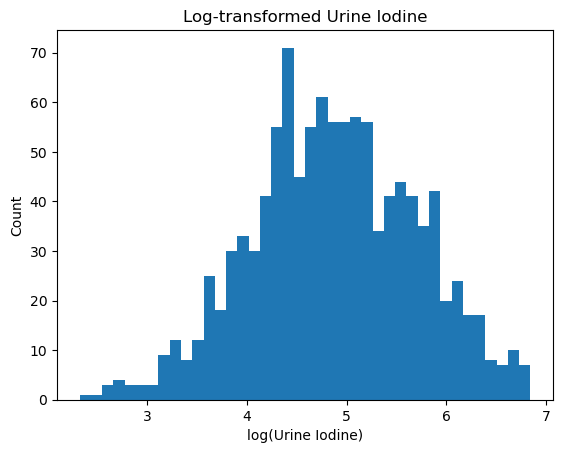

In [111]:
plt.hist(urine_iodine_clean['log_uio'], bins=40)
plt.title("Log-transformed Urine Iodine")
plt.xlabel("log(Urine Iodine)")
plt.ylabel("Count")
plt.show()

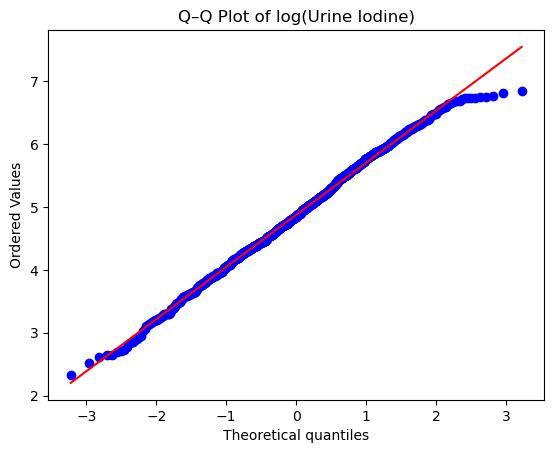

In [112]:
stats.probplot(urine_iodine_clean['log_uio'], dist="norm", plot=plt)
plt.title("Q–Q Plot of log(Urine Iodine)")
plt.show()

In [113]:
urine_iodine_clean[['bmi','log_uio']].corr()

,bmi,log_uio
bmi,1.00000,-0.02851
log_uio,-0.02851,1.00000


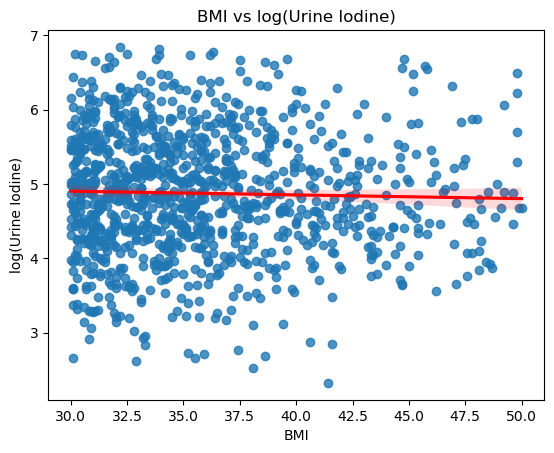

In [114]:
sns.regplot(x='bmi',y='log_uio',data=urine_iodine_clean,line_kws={"color": "red"})
plt.xlabel("BMI")
plt.ylabel("log(Urine Iodine)")
plt.title("BMI vs log(Urine Iodine)")
plt.show()

In [115]:
# Create a mapping for gender labels
gender_labels = {1: "Male", 2: "Female"}

# Replace gender values with text labels for plotting
urine_iodine_clean["gender_label"] = urine_iodine_clean["gender"].map(gender_labels)

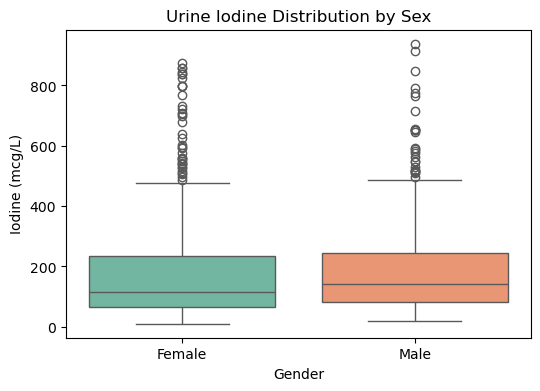

In [116]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender_label", y="urine_iodine", data=urine_iodine_clean, palette="Set2")
plt.title("Urine Iodine Distribution by Sex")
plt.ylabel("Iodine (mcg/L)")
plt.xlabel("Gender")
plt.show()

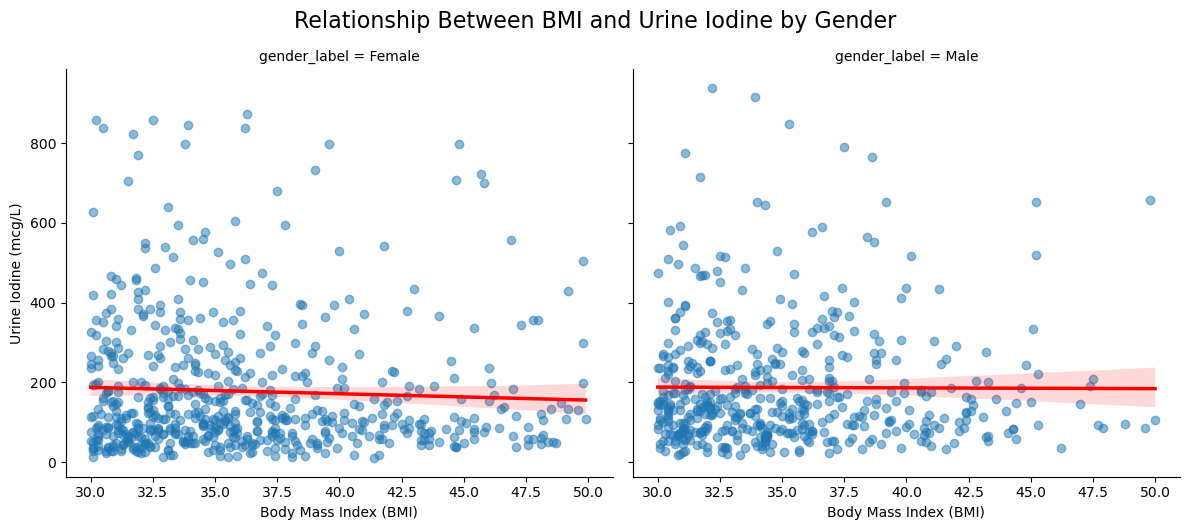

In [117]:
# Plot
g = sns.lmplot(
    x="bmi",
    y="urine_iodine",
    col="gender_label",  # use the new label column
    data=urine_iodine_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "linewidth": 2.5}
)

# Add an overall title
g.fig.suptitle("Relationship Between BMI and Urine Iodine by Gender", fontsize=16, y=1.05)

# Add axis labels
g.set_axis_labels("Body Mass Index (BMI)", "Urine Iodine (mcg/L)")

plt.show()

In [118]:
for gender, df_group in urine_iodine_clean.groupby('gender_label'):
    corr = df_group[['bmi', 'urine_iodine']].corr().iloc[0, 1]
    print(f"Correlation between BMI and urine iodine for {gender}: {corr:.3f}")

Correlation between BMI and urine iodine for Female: -0.048
Correlation between BMI and urine iodine for Male: -0.005


**Log Transformed Urine Iodine and Gender**

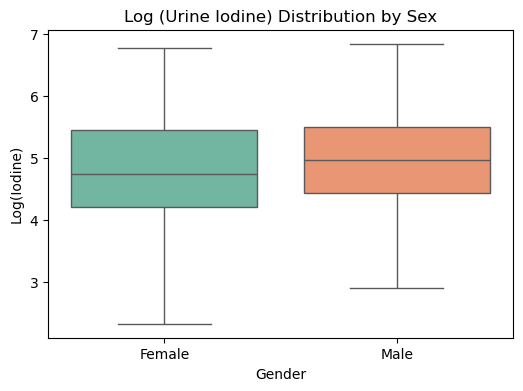

In [119]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender_label", y="log_uio", data=urine_iodine_clean, palette="Set2")
plt.title("Log (Urine Iodine) Distribution by Sex")
plt.ylabel("Log(Iodine)")
plt.xlabel("Gender")
plt.show()

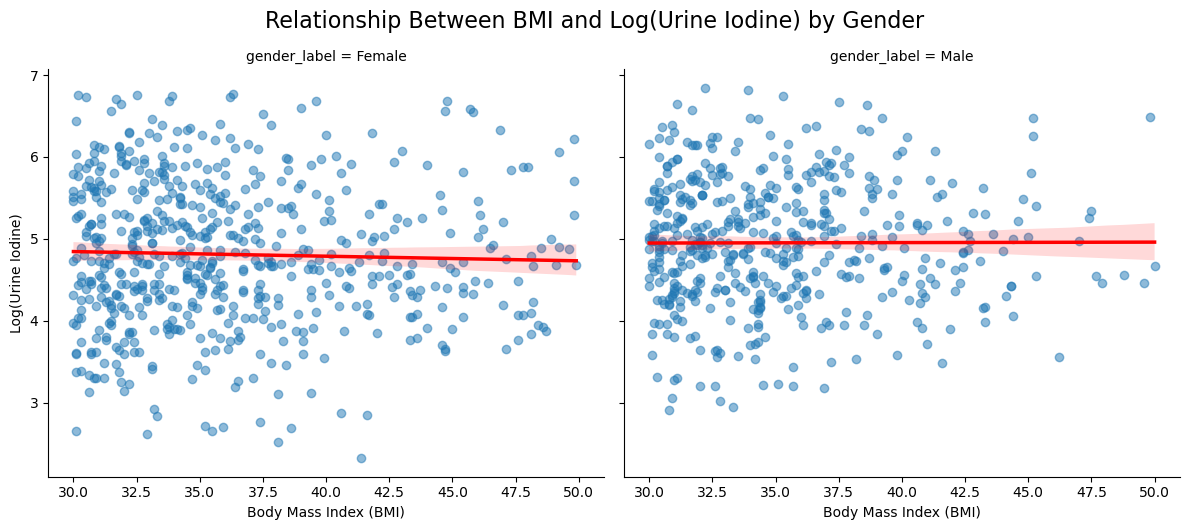

In [120]:
# Plot
g = sns.lmplot(
    x="bmi",
    y="log_uio",
    col="gender_label",  # use the new label column
    data=urine_iodine_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "linewidth": 2.5}
)

# Add an overall title
g.fig.suptitle("Relationship Between BMI and Log(Urine Iodine) by Gender", fontsize=16, y=1.05)

# Add axis labels
g.set_axis_labels("Body Mass Index (BMI)", "Log(Urine Iodine)")

plt.show()

In [121]:
for gender, df_group in urine_iodine_clean.groupby('gender_label'):
    corr_logio = df_group[['bmi', 'log_uio']].corr().iloc[0, 1]
    print(f"Correlation between BMI and urine iodine for {gender}: {corr_logio:.3f}")

Correlation between BMI and urine iodine for Female: -0.032
Correlation between BMI and urine iodine for Male: 0.003


### Multivariable Regression

In [122]:
alb_cols   = urine_alb_clean[['participant_id', 'log_ualb']]
creat_cols = urine_cr[['participant_id', 'log_ucr']]
io_cols = urine_iodine_clean[['participant_id', 'log_uio']]
bmi_cols   = adults_filtered[['participant_id', 'bmi', 'gender']]

In [123]:
df_mult = alb_cols.merge(creat_cols, on='participant_id') \
             .merge(io_cols, on='participant_id') \
             .merge(bmi_cols, on='participant_id')

In [124]:
df_mult.describe

<bound method NDFrame.describe of       participant_id  log_ualb   log_ucr   log_uio   bmi  gender
0           109266.0  1.704748  3.583519  3.923952  37.8     2.0
1           109274.0  2.549445  4.787492  5.580861  30.2     1.0
2           109316.0  1.774952  4.219508  4.383276  30.5     2.0
3           109317.0  2.944439  5.533389  4.763028  30.1     2.0
4           109321.0  2.572612  5.560682  5.709102  33.2     2.0
...              ...       ...       ...       ...   ...     ...
1079        124759.0  0.875469  4.094345  3.676301  31.7     2.0
1080        124770.0  2.949688  5.327876  5.808443  45.1     1.0
1081        124784.0  3.471966  5.942799  4.821088  34.2     2.0
1082        124788.0  1.163151  4.430817  5.138149  33.6     1.0
1083        124794.0  0.262364  4.158883  5.313206  42.8     1.0

[1084 rows x 6 columns]>

In [125]:
import statsmodels.api as sm

y = df_mult['bmi']

X = df_mult[['log_ualb', 'log_ucr', 'log_uio']]  
X = sm.add_constant(X)  # adds intercept

In [126]:
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    bmi   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     6.386
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           0.000274
Time:                        13:47:52   Log-Likelihood:                -3207.4
No. Observations:                1084   AIC:                             6423.
Df Residuals:                    1080   BIC:                             6443.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.6027      1.080     32.045      0.000      32.484      36.721
log_ualb       0.3169      0.132      2.403      0.016       0.058       0.576
log_ucr        0.6220      0.258      2.413      0.016       0.116       1.128
log_uio       -0.5340      0.198     -2.692      0.007      -0.923      -0.145
==============================================================================
Omnibus:                      129.720   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              176.296
Skew:                           0.973   Prob(JB):                     5.22e-39
Kurtosis:                       3.339   Cond. No.                         56.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Conclusion

Based on the analysis performed with NHANES urine dataset, there was no substantial correlation between the urine creatinine, albumin, or iodine with BMI overall. However, there was a weak correlation between the male cohort and urine albumin, with a positive correlation (higher BMI showed higher urine albumin in males p = 0.002). 

These findings are reasonable since the urine labs are more related to kidney function and overall nutritional status of a person. Obesity is the pathology caused by metabolic imbalance. 

The next analysis that should be peformed should be comparing how these values differ between normal BMI popultion and obese BMI population. 